In [1]:
import pandas as pd

# LD files
alu_ins_path   = "/gpfs/data/user/shreyags/TE_work/replication_results/ld/snp_ALU_ins.ld"
line1_ins_path = "/gpfs/data/user/shreyags/TE_work/replication_results/ld/snp_LINE1_ins.ld"

# GTEx
eqtl_path = "/gpfs/data/user/shreyags/TE_work/data/eqtls/GTEx_v11_all_lead_eQTLs.tsv"

alu_ins_ld   = pd.read_csv(alu_ins_path, delim_whitespace=True)
line1_ins_ld = pd.read_csv(line1_ins_path, delim_whitespace=True)

print(f"ALU insertions  : {len(alu_ins_ld):,}")
print(f"LINE1 insertions: {len(line1_ins_ld):,}")

eqtl = pd.read_csv(eqtl_path, sep="\t", low_memory=False)
eqtl["chr"] = eqtl["chr"].astype(str).str.strip()
eqtl["variant_pos"] = pd.to_numeric(eqtl["variant_pos"], errors="coerce")

print(f"\nGTEx lead eQTLs : {len(eqtl):,}")
print(f"Unique genes    : {eqtl['gene_id'].nunique():,}")
print(f"Unique tissues  : {eqtl['tissue'].nunique():,}")

ALU insertions  : 5,439
LINE1 insertions: 660

GTEx lead eQTLs : 639,049
Unique genes    : 45,579
Unique tissues  : 50


In [2]:
def clean_te_variant(id_series):
    return id_series.str.extract(r'^([^:]+:[^:]+)')[0]

def extract_ld_snps_insertion(df, te_class, te_tag):
    df.columns = [
        "chr_a","bp_a","id_a",
        "chr_b","bp_b","id_b","r2"
    ]
    is_te_in_a = df["id_a"].str.contains(te_tag, na=False)
    te_col = df["id_a"].where(is_te_in_a, df["id_b"])
    return pd.DataFrame({
        "te_class" : te_class,
        "variant_type" : "Insertion",
        "te_variant" : clean_te_variant(te_col),
        "proxy_snp" : df["id_b"].where(is_te_in_a, df["id_a"]),
        "snp_chr" : df["chr_b"].where(is_te_in_a, df["chr_a"]).astype(str),
        "snp_pos" : df["bp_b"].where(is_te_in_a, df["bp_a"]).astype(int),
        "r2" : df["r2"]
    })

alu_ins = extract_ld_snps_insertion(
    alu_ins_ld,
    "Alu",
    "<INS:ME:ALU>"
)
line1_ins = extract_ld_snps_insertion(
    line1_ins_ld,
    "LINE1",
    "<INS:ME:LINE1>"
)

all_ld = pd.concat([
    alu_ins,
    line1_ins
], ignore_index=True)

all_ld["snp_chr"] = "chr" + all_ld["snp_chr"].astype(str)

print(f"Total LD pairs : {len(all_ld):,}")
print(f"Unique proxy SNPs : {all_ld['proxy_snp'].nunique():,}")
print(f"Unique TE variants : {all_ld['te_variant'].nunique():,}")
all_ld.groupby(["variant_type","te_class"]).size()

Total LD pairs : 6,099
Unique proxy SNPs : 5,921
Unique TE variants : 2,225


variant_type  te_class
Insertion     Alu         5439
              LINE1        660
dtype: int64

In [3]:
hits = all_ld.merge(
    eqtl,
    left_on=["snp_chr","snp_pos"],
    right_on=["chr","variant_pos"],
    how="inner"
)
print(f"Total overlaps : {len(hits):,}")
print(f"Unique TE variants : {hits['te_variant'].nunique():,}")
print(f"Unique genes : {hits['gene_id'].nunique():,}")
print(f"Unique tissues : {hits['tissue'].nunique():,}")
hits.groupby(["variant_type","te_class"]).size()

Total overlaps : 303
Unique TE variants : 158
Unique genes : 190
Unique tissues : 50


variant_type  te_class
Insertion     Alu         274
              LINE1        29
dtype: int64

In [6]:
keep_cols = [
    "te_class",
    "te_variant",
    "proxy_snp",
    "r2",
    "gene_id",
    "gene_name",
    "tissue",
    "slope",
    "slope_se",
    "pval_beta",
    "qval"
]

hits_out = (
    hits[keep_cols]
    .drop_duplicates()
    .sort_values(
        [
            "te_class",
            "te_variant",
            "gene_name",
            "tissue"
        ]
    )
)
hits_out.head()

base = "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_tables"
hits_out.to_csv(
    f"{base}/mei_insertion_lead_eQTL_hits.csv",
    index=False
)
print(f"Insertions saved : {len(hits_out):,} rows")
print("\nBreakdown:")
print(hits_out.groupby("te_class").size())

Insertions saved : 303 rows

Breakdown:
te_class
Alu      274
LINE1     29
dtype: int64


In [5]:
import pandas as pd

csv_file = "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_tables/mei_insertion_lead_eQTL_hits.csv"
alu_bed = "/gpfs/data/user/shreyags/af_all_ALU_not_in_ANY_SR.txt"
line1_bed = "/gpfs/data/user/shreyags/af_all_LINE1_not_in_ANY_SR.txt"

# Read eQTL hits
df = pd.read_csv(csv_file)

# Extract chr:pos from te_variant
df["chr_pos"] = (
    "chr"
    + df["te_variant"].str.split(":").str[0]
    + ":"
    + df["te_variant"].str.split(":").str[1]
)

alu = pd.read_csv(alu_bed, sep="\t", header=None, names=["chr", "start", "end"])
line1 = pd.read_csv(line1_bed, sep="\t", header=None, names=["chr", "start", "end"])
alu["chr_pos"] = alu["chr"] + ":" + alu["start"].astype(str)
line1["chr_pos"] = line1["chr"] + ":" + line1["start"].astype(str)

eqtl = df.drop_duplicates(subset="te_variant")

# Find overlaps
alu_hits = eqtl[eqtl["chr_pos"].isin(set(alu["chr_pos"]))]
line1_hits = eqtl[eqtl["chr_pos"].isin(set(line1["chr_pos"]))]

print(f"Unique eQTL insertions: {len(eqtl)}")
print(f"Alu insertions found in ALU_not_in_ANY_SR: {len(alu_hits)}")
print(f"LINE1 insertions found in LINE1_not_in_ANY_SR: {len(line1_hits)}")

print("\nAlu matches:")
display(alu_hits)
print("\nLINE1 matches:")
display(line1_hits)

Unique eQTL insertions: 158
Alu insertions found in ALU_not_in_ANY_SR: 0
LINE1 insertions found in LINE1_not_in_ANY_SR: 0

Alu matches:


,te_class,te_variant,proxy_snp,r2,gene_id,gene_name,tissue,slope,slope_se,pval_beta,qval,chr_pos



LINE1 matches:


,te_class,te_variant,proxy_snp,r2,gene_id,gene_name,tissue,slope,slope_se,pval_beta,qval,chr_pos


  [INS eQTL] parsed columns: ['te_class', 'te_variant', 'proxy_snp', 'r2', 'gene_id', 'gene_name', 'tissue', 'slope', 'slope_se', 'pval_beta', 'qval']
  [INS eQTL] Significant rows (q<0.05): 303 / 303
  [INS eQTL] lookup entries: 158
  [INS GWAS] parsed columns: ['variant_type', 'te_variant', 'proxy_snp', 'SNPS', 'r2', 'MAPPED_GENE', 'DISEASE/TRAIT', 'P-VALUE', 'OR or BETA', '95% CI (TEXT)', 'snp_chr', 'snp_pos', 'DATE ADDED TO CATALOG', 'PUBMEDID', 'FIRST AUTHOR', 'DATE', 'JOURNAL', 'LINK', 'STUDY', 'INITIAL SAMPLE SIZE', 'REPLICATION SAMPLE SIZE', 'REGION', 'CHR_ID', 'CHR_POS', 'REPORTED GENE(S)', 'UPSTREAM_GENE_ID', 'DOWNSTREAM_GENE_ID', 'SNP_GENE_IDS', 'UPSTREAM_GENE_DISTANCE', 'DOWNSTREAM_GENE_DISTANCE', 'STRONGEST SNP-RISK ALLELE', 'MERGED', 'SNP_ID_CURRENT', 'CONTEXT', 'INTERGENIC', 'RISK ALLELE FREQUENCY', 'PVALUE_MLOG', 'P-VALUE (TEXT)', 'PLATFORM [SNPS PASSING QC]', 'CNV']
  [INS GWAS] lookup entries: 131
  [ALU_INS] 64 / 239 variants with range > 0.4
  [LINE1_INS] 7 / 25 var

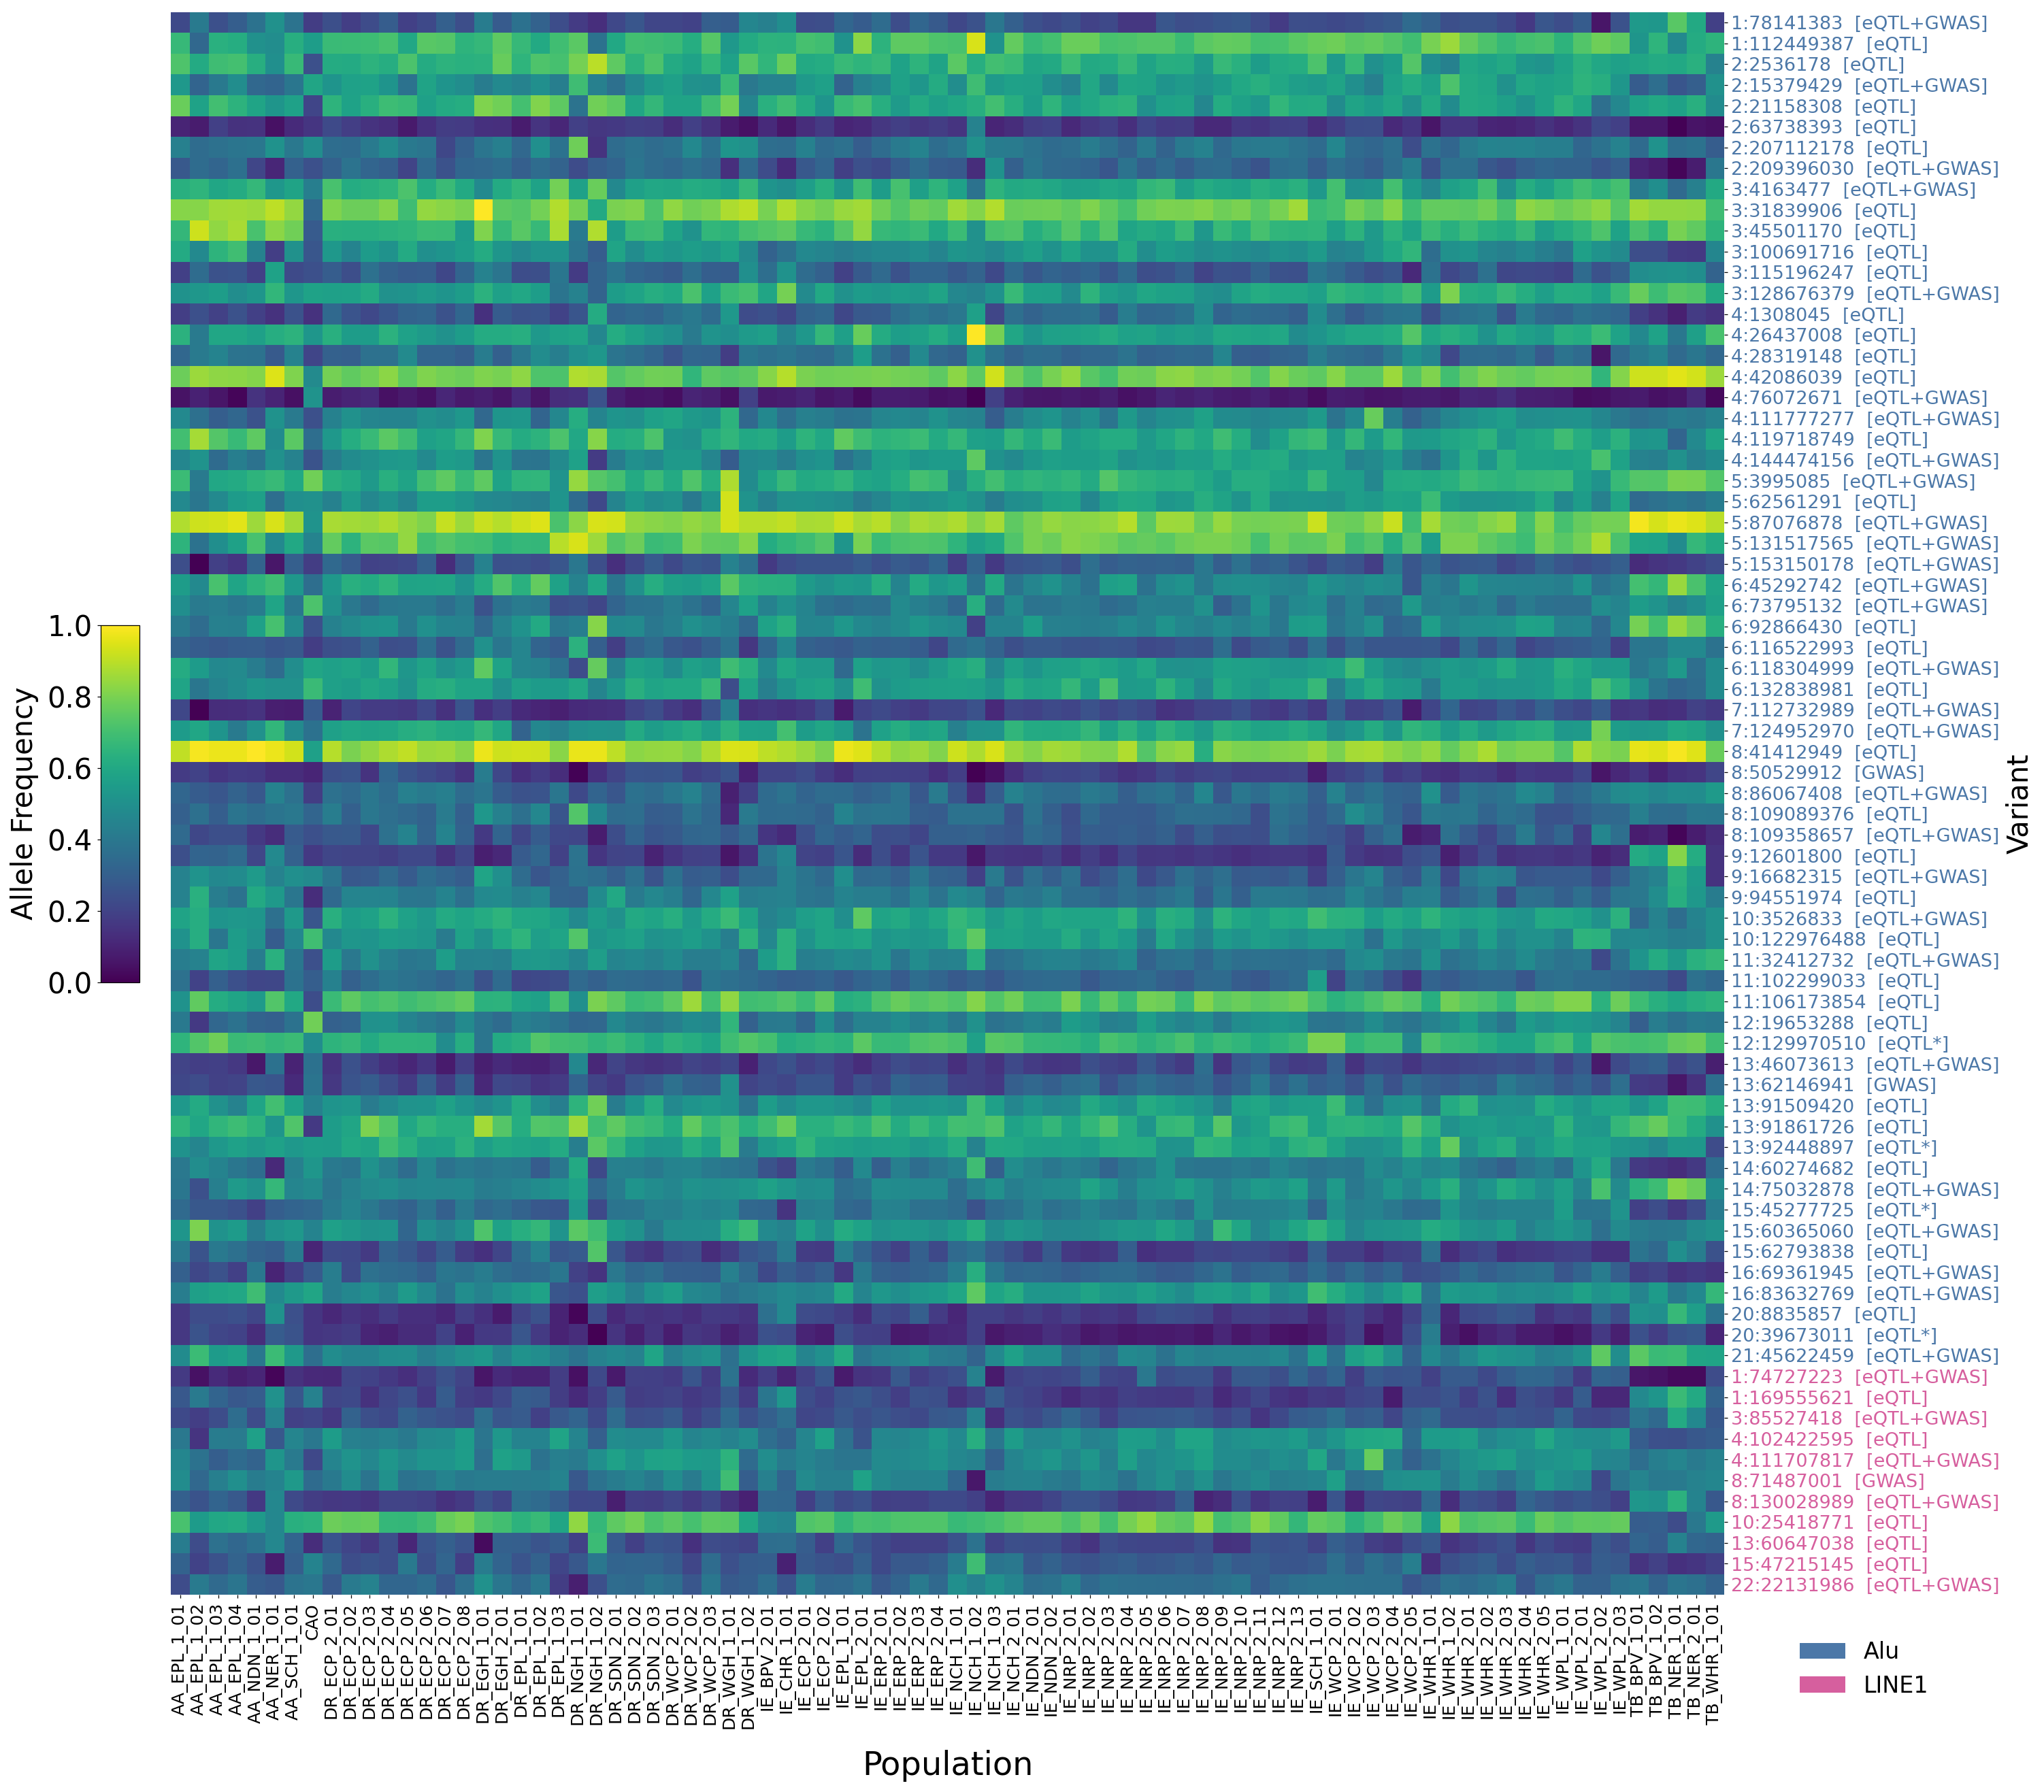


Done.


In [1]:
import os
from collections import defaultdict

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from PIL import Image
import fig_style as S

S.set_style()

OUTDIR = "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/figures/figure3/"

AF_FILE       = "/gpfs/data/user/shreyags/TE_work/analysis/pop_af_out_new/INS_pop_af.tsv"
INS_EQTL_FILE = "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_tables/mei_insertion_lead_eQTL_hits.csv"
INS_GWAS_FILE = "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_tables/gwas_ld_hits_insertions.csv"

ALU_INS_SITES        = "/gpfs/data/user/shreyags/heatmaps_fig2_content/dedup_eqtl_alu_ins.txt"
LINE1_INS_SITES      = "/gpfs/data/user/shreyags/heatmaps_fig2_content/dedup_eqtl_line1_ins.txt"
ALU_INS_GWAS_SITES   = "/gpfs/data/user/shreyags/heatmaps_fig2_content/dedup_gwas_alu_ins.txt"
LINE1_INS_GWAS_SITES = "/gpfs/data/user/shreyags/heatmaps_fig2_content/dedup_gwas_line1_ins.txt"

INS_TSV    = "/gpfs/data/user/shweta_lab/data/TE/eqtls/eqtls_gtex_hg38_INS.tsv"
BP_BUFFER  = 20

ALU_INS_COLOR   = S.TE_PALETTE["Alu"]
LINE1_INS_COLOR = S.TE_PALETTE["LINE1"]

RANGE_THRESHOLD         = 0.4
RANGE_THRESHOLD_S2_ONLY = 0.6
QVAL_THRESHOLD          = 0.05

EXCLUDE_VARIANTS = {
    "chr12:21970862", "chr12:101056915", "chr6:158783399", "chr20:30145689", 
    "chr17:34302255", "chr6:128724707", "chr2:127881330", "chr14:37890438", 
    "chr12:21933021", "chr2:66431859", "chr17:13141838", "chr6:40079170", 
    "chr8:106195660", "chr22:19373937", "chr2:174871217", "chr11:7591466", 
    "chr18:62046501", "chr18:40747687", "chr14:98028056", "chr6:19136878",
    "chr10:52707182", "chr14:40747687", "chr10:27640999", "chr12:27711878",
    "chr15:40747687", "chr1:234669982", "chr17:48427640", "chr1:69625389",
}

# DPI                  = 300
# B_WIDTH_PX           = 8673
# CAT_FIG_WIDTH        = B_WIDTH_PX / DPI
CAT_ROW_HEIGHT       = 0.22          
CAT_MIN_FIG_HEIGHT   = 6.0

CAT_YLABEL_FONTSIZE  = 13            
CAT_DENDRO_RATIO     = (0.075, 0.001)

PANEL_B_RIGHT_MARGIN = 0.32
PANEL_B_LEFT_MARGIN  = 0.09

CBAR_SIZE = "2.5%"
CBAR_PAD  = "2.0%"
CBAR_HEIGHT_IN = 3.5

XTICK_PAD = 3
YTICK_PAD = 2

PANEL_B_TOP_MARGIN    = 0.02
PANEL_B_BOTTOM_MARGIN = 0.09

os.makedirs(OUTDIR, exist_ok=True)

af = pd.read_csv(AF_FILE, sep="\t")

def normalise_te_variant(v):
    v = str(v).strip()
    if not v.startswith("chr"):
        v = "chr" + v
    parts = v.split(":")
    kept = [parts[0]]
    for p in parts[1:]:
        if p.lstrip("-").isdigit():
            kept.append(p)
        else:
            break
    return ":".join(kept)

def display_variant(v):
    v = str(v)
    return v[3:] if v.startswith("chr") else v

def chrom_sort_key(variant):
    parts = str(variant).split(":")
    chrom  = parts[0][3:] if parts[0].startswith("chr") else parts[0]
    if chrom.isdigit():
        chrom_num = int(chrom)
    elif chrom.upper() == "X":
        chrom_num = 23
    elif chrom.upper() == "Y":
        chrom_num = 24
    elif chrom.upper() in ("M", "MT"):
        chrom_num = 25
    else:
        chrom_num = 99
    pos = 0
    if len(parts) > 1 and parts[1].lstrip("-").isdigit():
        pos = int(parts[1])
    return (chrom_num, pos)

def build_eqtl_lookup(path, label):
    df = pd.read_csv(path, sep=None, engine="python")
    print(f"  [{label} eQTL] parsed columns: {list(df.columns)}")
    df["variant_norm"] = df["te_variant"].apply(normalise_te_variant)

    qval_col = "qval"
    r2_col   = "r2"
    df[qval_col]      = pd.to_numeric(df[qval_col],      errors="coerce")
    df[r2_col]        = pd.to_numeric(df[r2_col],        errors="coerce")
    df["pval_beta"]   = pd.to_numeric(df["pval_beta"],   errors="coerce")

    n_sig = (df[qval_col] < QVAL_THRESHOLD).sum()
    print(f"  [{label} eQTL] Significant rows (q<{QVAL_THRESHOLD}): {n_sig} / {len(df)}")

    df = df.sort_values("pval_beta")

    records = []
    for variant_norm, group in df.groupby("variant_norm", sort=False):
        top_hit = group.iloc[0]
        records.append({"variant": variant_norm, "gene_name": top_hit["gene_name"],
                        "slope": top_hit["slope"], "r2": top_hit[r2_col]})

    lookup = pd.DataFrame(records).set_index("variant")
    print(f"  [{label} eQTL] lookup entries: {len(lookup)}")
    return lookup

def build_gwas_lookup(path, label):
    df = pd.read_csv(path, sep=None, engine="python")
    print(f"  [{label} GWAS] parsed columns: {list(df.columns)}")
    df["variant_norm"] = df["te_variant"].apply(normalise_te_variant)
    # not p_value/effect_size/trait -- map them here.
    df["p_value"]     = pd.to_numeric(df["P-VALUE"],  errors="coerce")
    df["r2"]          = pd.to_numeric(df["r2"],       errors="coerce")
    df["effect_size"] = pd.to_numeric(df["OR or BETA"], errors="coerce")
    df["trait"]       = df["DISEASE/TRAIT"]

    lookup = (
        df.sort_values("p_value")
          .groupby("variant_norm", as_index=False).first()
          [["variant_norm","trait","MAPPED_GENE","r2","effect_size"]]
          .rename(columns={"variant_norm":"variant","MAPPED_GENE":"gwas_gene","r2":"gwas_r2"})
          .set_index("variant")
    )
    print(f"  [{label} GWAS] lookup entries: {len(lookup)}")
    return lookup

eqtl_lookup_ins = build_eqtl_lookup(INS_EQTL_FILE, "INS")
gwas_lookup_ins  = build_gwas_lookup(INS_GWAS_FILE,  "INS")

def load_ins_sites(path):
    s = pd.read_csv(path, header=None, names=["variant"])
    s["variant"] = s["variant"].str.strip()
    return s

def build_mat(sites_df):
    heat    = af[af["variant"].isin(sites_df["variant"])].copy()
    af_cols = [c for c in heat.columns if c.endswith("_AF")]
    mat     = heat.set_index("variant")[af_cols].fillna(0)
    mat.columns = [c.replace("_AF","") for c in mat.columns]
    return mat

def build_mat_for_variants(variant_list):
    return build_mat(pd.DataFrame({"variant": list(variant_list)}))

def high_range_subset(mat, label):
    rng  = mat.max(axis=1) - mat.min(axis=1)
    var  = mat.var(axis=1)
    high = rng[rng > RANGE_THRESHOLD].index
    print(f"  [{label}] {len(high)} / {len(mat)} variants with range > {RANGE_THRESHOLD}")
    return mat.loc[high], rng, var

variant_configs = [
    ("ALU_INS",   load_ins_sites(ALU_INS_SITES),   load_ins_sites(ALU_INS_GWAS_SITES),
     ALU_INS_COLOR,   eqtl_lookup_ins, gwas_lookup_ins),
    ("LINE1_INS", load_ins_sites(LINE1_INS_SITES),  load_ins_sites(LINE1_INS_GWAS_SITES),
     LINE1_INS_COLOR, eqtl_lookup_ins, gwas_lookup_ins),
]

mats_high     = []
ranges_all    = {}
variance_all  = {}
colors_map    = {}
eqtl_map      = {}
gwas_map      = {}

for vtype, eqtl_sites, gwas_sites, color, eqtl_lookup, gwas_lookup in variant_configs:
    all_variants = pd.concat([eqtl_sites[["variant"]], gwas_sites[["variant"]]]).drop_duplicates("variant")
    mat            = build_mat(all_variants)
    mat_high, rng, var = high_range_subset(mat, vtype)
    mats_high.append(mat_high)

    for v in mat_high.index:
        ranges_all[v]   = rng[v]
        variance_all[v] = var[v]
        colors_map[v]   = color
        eqtl_map[v]     = eqtl_lookup
        gwas_map[v]     = gwas_lookup

mega_mat = pd.concat(mats_high)
mega_mat = mega_mat[~mega_mat.index.duplicated(keep="first")]
print(f"\nMega matrix, range-based (pre-filter): {len(mega_mat)} variants x {mega_mat.shape[1]} populations")

# Keep only annotated variants
annotated = [v for v in mega_mat.index if v in eqtl_map[v].index or v in gwas_map[v].index]
mega_mat  = mega_mat.loc[annotated]

# Exclusion list
before_excl = len(mega_mat)
mega_mat    = mega_mat[~mega_mat.index.isin(EXCLUDE_VARIANTS)]
print(f"  Explicitly excluded {before_excl - len(mega_mat)} variants (range-based)")

print("\nBuilding script-2 cross-check index...")

def parse_af_variant(v):
    parts = str(v).split(":")
    chrom = parts[0] if parts[0].startswith("chr") else "chr" + parts[0]
    try:    start = int(parts[1])
    except: return None, None, None
    end = int(parts[2]) if len(parts) >= 3 and parts[2].lstrip("-").isdigit() else None
    return chrom, start, end

def parse_tsv_pos(s):
    parts = str(s).split(":")
    chrom = parts[0] if parts[0].startswith("chr") else "chr" + parts[0]
    try:    pos = int(parts[1])
    except: return None, None
    return chrom, pos

parsed       = af["variant"].apply(parse_af_variant)
af["af_chrom"] = [p[0] for p in parsed]
af["af_start"] = [p[1] for p in parsed]
af["af_end"]   = [p[2] for p in parsed]
af_ins_full    = af[af["af_end"].isna()].copy()

def build_pos_index(df):
    idx = defaultdict(list)
    for i, row in df.iterrows():
        idx[row["af_chrom"]].append((row["af_start"], i))
    return {ch: sorted(e) for ch, e in idx.items()}

ins_pos_idx_full = build_pos_index(af_ins_full)

def find_af_matches(chrom, pos, pos_index, buffer=BP_BUFFER):
    return [i for (af_pos, i) in pos_index.get(chrom, []) if abs(af_pos - pos) <= buffer]

def match_script2_eqtls(tsv_path, pos_index):
    df = pd.read_csv(tsv_path, sep="\t", dtype=str)
    causal_col = "isCausal" if "isCausal" in df.columns else df.columns[8]
    print(f"  Using causal column: '{causal_col}'")
    collapsed = {}
    for _, row in df.iterrows():
        chrom, pos = parse_tsv_pos(row["chr_pos_hg38"])
        if chrom is None:
            continue
        hits = find_af_matches(chrom, pos, pos_index)
        if not hits:
            continue
        best_idx       = min(hits, key=lambda i: abs(af.loc[i, "af_start"] - pos))
        af_variant_id  = af.loc[best_idx, "variant"]
        entry          = collapsed.setdefault(af_variant_id, {
            "gene_betas":  {},
            "te_type":     row.get("te_type"),
            "gene_causal": {}
        })
        entry["gene_betas"][row["gene_symbol"]]  = row["beta"]
        entry["gene_causal"][row["gene_symbol"]] = str(row.get(causal_col,"")).strip().lower() == "true"
    return collapsed

script2_eqtl_map_full = match_script2_eqtls(INS_TSV, ins_pos_idx_full)
print(f"  Script-2 matches for {len(script2_eqtl_map_full)} AF insertion variants")

script2_eqtl_map = {v: d["gene_betas"] for v, d in script2_eqtl_map_full.items()}

S2_COLOR_BY_TE = {"ALU": ALU_INS_COLOR, "LINE1": LINE1_INS_COLOR}

script2_only_candidates = [
    v for v in script2_eqtl_map_full
    if v not in mega_mat.index
]
rescued = []
if script2_only_candidates:
    cand_mat = build_mat_for_variants(script2_only_candidates)
    cand_rng = cand_mat.max(axis=1) - cand_mat.min(axis=1)
    cand_var = cand_mat.var(axis=1)
    rescued  = [v for v in cand_rng[cand_rng > RANGE_THRESHOLD_S2_ONLY].index
                if v not in EXCLUDE_VARIANTS]
    print(f"  Rescued script-2-only variants (range > {RANGE_THRESHOLD_S2_ONLY}): {len(rescued)}")
    if rescued:
        empty_e = eqtl_lookup_ins.iloc[0:0]
        empty_g = gwas_lookup_ins.iloc[0:0]
        mega_mat = pd.concat([mega_mat, cand_mat.loc[rescued]])
        for v in rescued:
            ranges_all[v]   = cand_rng[v]
            variance_all[v] = cand_var[v]
            te_type        = script2_eqtl_map_full[v].get("te_type")
            colors_map[v]  = S2_COLOR_BY_TE.get(te_type, ALU_INS_COLOR)
            eqtl_map[v]    = empty_e
            gwas_map[v]    = empty_g

script2_only_variants = set(rescued)

TYPE_ORDER = {ALU_INS_COLOR: 0, LINE1_INS_COLOR: 1}

def _full_sort_key(v):
    return (TYPE_ORDER.get(colors_map[v], 2),) + chrom_sort_key(v)

mega_mat = mega_mat.loc[sorted(mega_mat.index, key=_full_sort_key)]

def make_label_categories(variant):
    """
    Concise shorthand label:
      eQTL   = TE eQTL (script-2), whether or not it's also LD with an eQTL
      eQTL*  = LD with an eQTL SNP only (no TE eQTL support)
      GWAS   = LD with a GWAS SNP
    Combined with '+', e.g. "1:12345  [eQTL+GWAS]" or "1:12345  [eQTL*]"
    """
    elookup = eqtl_map.get(variant)
    glookup = gwas_map.get(variant)

    has_ld_eqtl = elookup is not None and variant in elookup.index
    has_te_eqtl = variant in script2_eqtl_map

    eqtl_str = None
    if has_te_eqtl:
        eqtl_str = "eQTL"
    elif has_ld_eqtl:
        eqtl_str = "eQTL*"

    gwas_str = None
    if glookup is not None and variant in glookup.index:
        gwas_str = "GWAS"

    cats  = [s for s in [eqtl_str, gwas_str] if s]
    inner = "+".join(cats) if cats else "none"
    return f"{display_variant(variant)}  [{inner}]"

legend_handles = [
    mpatches.Patch(facecolor=ALU_INS_COLOR,   label="Alu"),
    mpatches.Patch(facecolor=LINE1_INS_COLOR, label="LINE1"),
]

def _base_clustermap(figsize, mat, dendrogram_ratio=(0.1, 0.001), fig_height=None,
                      subplot_margins=None):
    if fig_height is None:
        fig_height = max(12, len(mat) * 0.28)

    fig_width = figsize[0]

    g = sns.clustermap(
        mat,
        cmap="viridis",
        figsize=(fig_width, fig_height),
        method="average", metric="euclidean",
        row_cluster=False, col_cluster=False,
        dendrogram_ratio=dendrogram_ratio,
        linewidths=0,
        xticklabels=True, yticklabels=True,
        cbar_pos=None,
    )

    g.fig.set_facecolor("white")
    g.ax_heatmap.set_facecolor("white")
    g.ax_heatmap.spines["top"].set_visible(False)
    g.ax_heatmap.spines["right"].set_visible(False)

    plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=12, ha="center")

    g.ax_heatmap.tick_params(axis="x", pad=XTICK_PAD)
    g.ax_heatmap.tick_params(axis="y", pad=YTICK_PAD)

    g.ax_heatmap.set_xlabel("Population", fontsize=23, labelpad=15)
    g.ax_heatmap.set_ylabel("Variant",fontsize=20)

    pos = g.ax_heatmap.get_position()
    cbar_w_frac = float(CBAR_SIZE.strip("%")) / 100 * pos.width
    cbar_pad_frac = float(CBAR_PAD.strip("%")) / 100 * pos.width
    cbar_h_frac = CBAR_HEIGHT_IN / fig_height
    cbar_h_frac = min(cbar_h_frac, pos.height)
    cbar_y0 = pos.y0 + (pos.height - cbar_h_frac) / 2
    cax = g.fig.add_axes([pos.x0 - cbar_pad_frac - cbar_w_frac, cbar_y0,
                          cbar_w_frac, cbar_h_frac])
    cbar = g.fig.colorbar(g.ax_heatmap.collections[0], cax=cax)
    cbar.ax.yaxis.set_ticks_position("left")
    cbar.ax.yaxis.set_label_position("left")
    cbar.set_label("Allele Frequency", labelpad=6, fontsize=20)
    cbar.ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
    cbar.ax.tick_params(labelsize=20)
    g.cax = cax

    return g

def _colour_ticks(g, variants):
    for tick, v in zip(g.ax_heatmap.get_yticklabels(), variants):
        tick.set_color(colors_map[v])

def make_heatmap_categories():
    fig_height = max(CAT_MIN_FIG_HEIGHT, len(mega_mat) * CAT_ROW_HEIGHT)
    g = _base_clustermap((18, None), mega_mat,
                          dendrogram_ratio=CAT_DENDRO_RATIO,
                          fig_height=fig_height,
                          subplot_margins=None)

    variants   = list(mega_mat.index)
    new_labels = [make_label_categories(v) for v in variants]
    g.ax_heatmap.set_yticklabels(new_labels, fontsize=CAT_YLABEL_FONTSIZE)
    _colour_ticks(g, variants)

    heatmap_pos = g.ax_heatmap.get_position()

    g.fig.legend(handles=legend_handles, loc="upper left",
                 bbox_to_anchor=(heatmap_pos.x1 + 0.03, heatmap_pos.y0 - 0.015),
                 ncol=1, frameon=False, fontsize=16)

    composite_outfile = os.path.join(OUTDIR, "panel_A_composite.png")
    g.fig.savefig(
        composite_outfile,
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.02,   
        facecolor="white"
    )
    actual_w_in, actual_h_in = g.fig.get_size_inches()
    print("Saved PNG:", Image.open(composite_outfile).size)

    plt.show()
    plt.close(g.fig)

make_heatmap_categories()

print("\nDone.")

/gpfs/data/user/shreyags/TE_work/new_results/manuscript/figures/figure3/panel_A_composite.png
Exists: True
Modified: 1785037735.659921
PIL size: (5952, 5218)
Panel A: 5952x5218px  (19.84x17.39in)
Panel B: 5952x1647px  (19.84x5.49in)
Composite: 19.84x23.03in


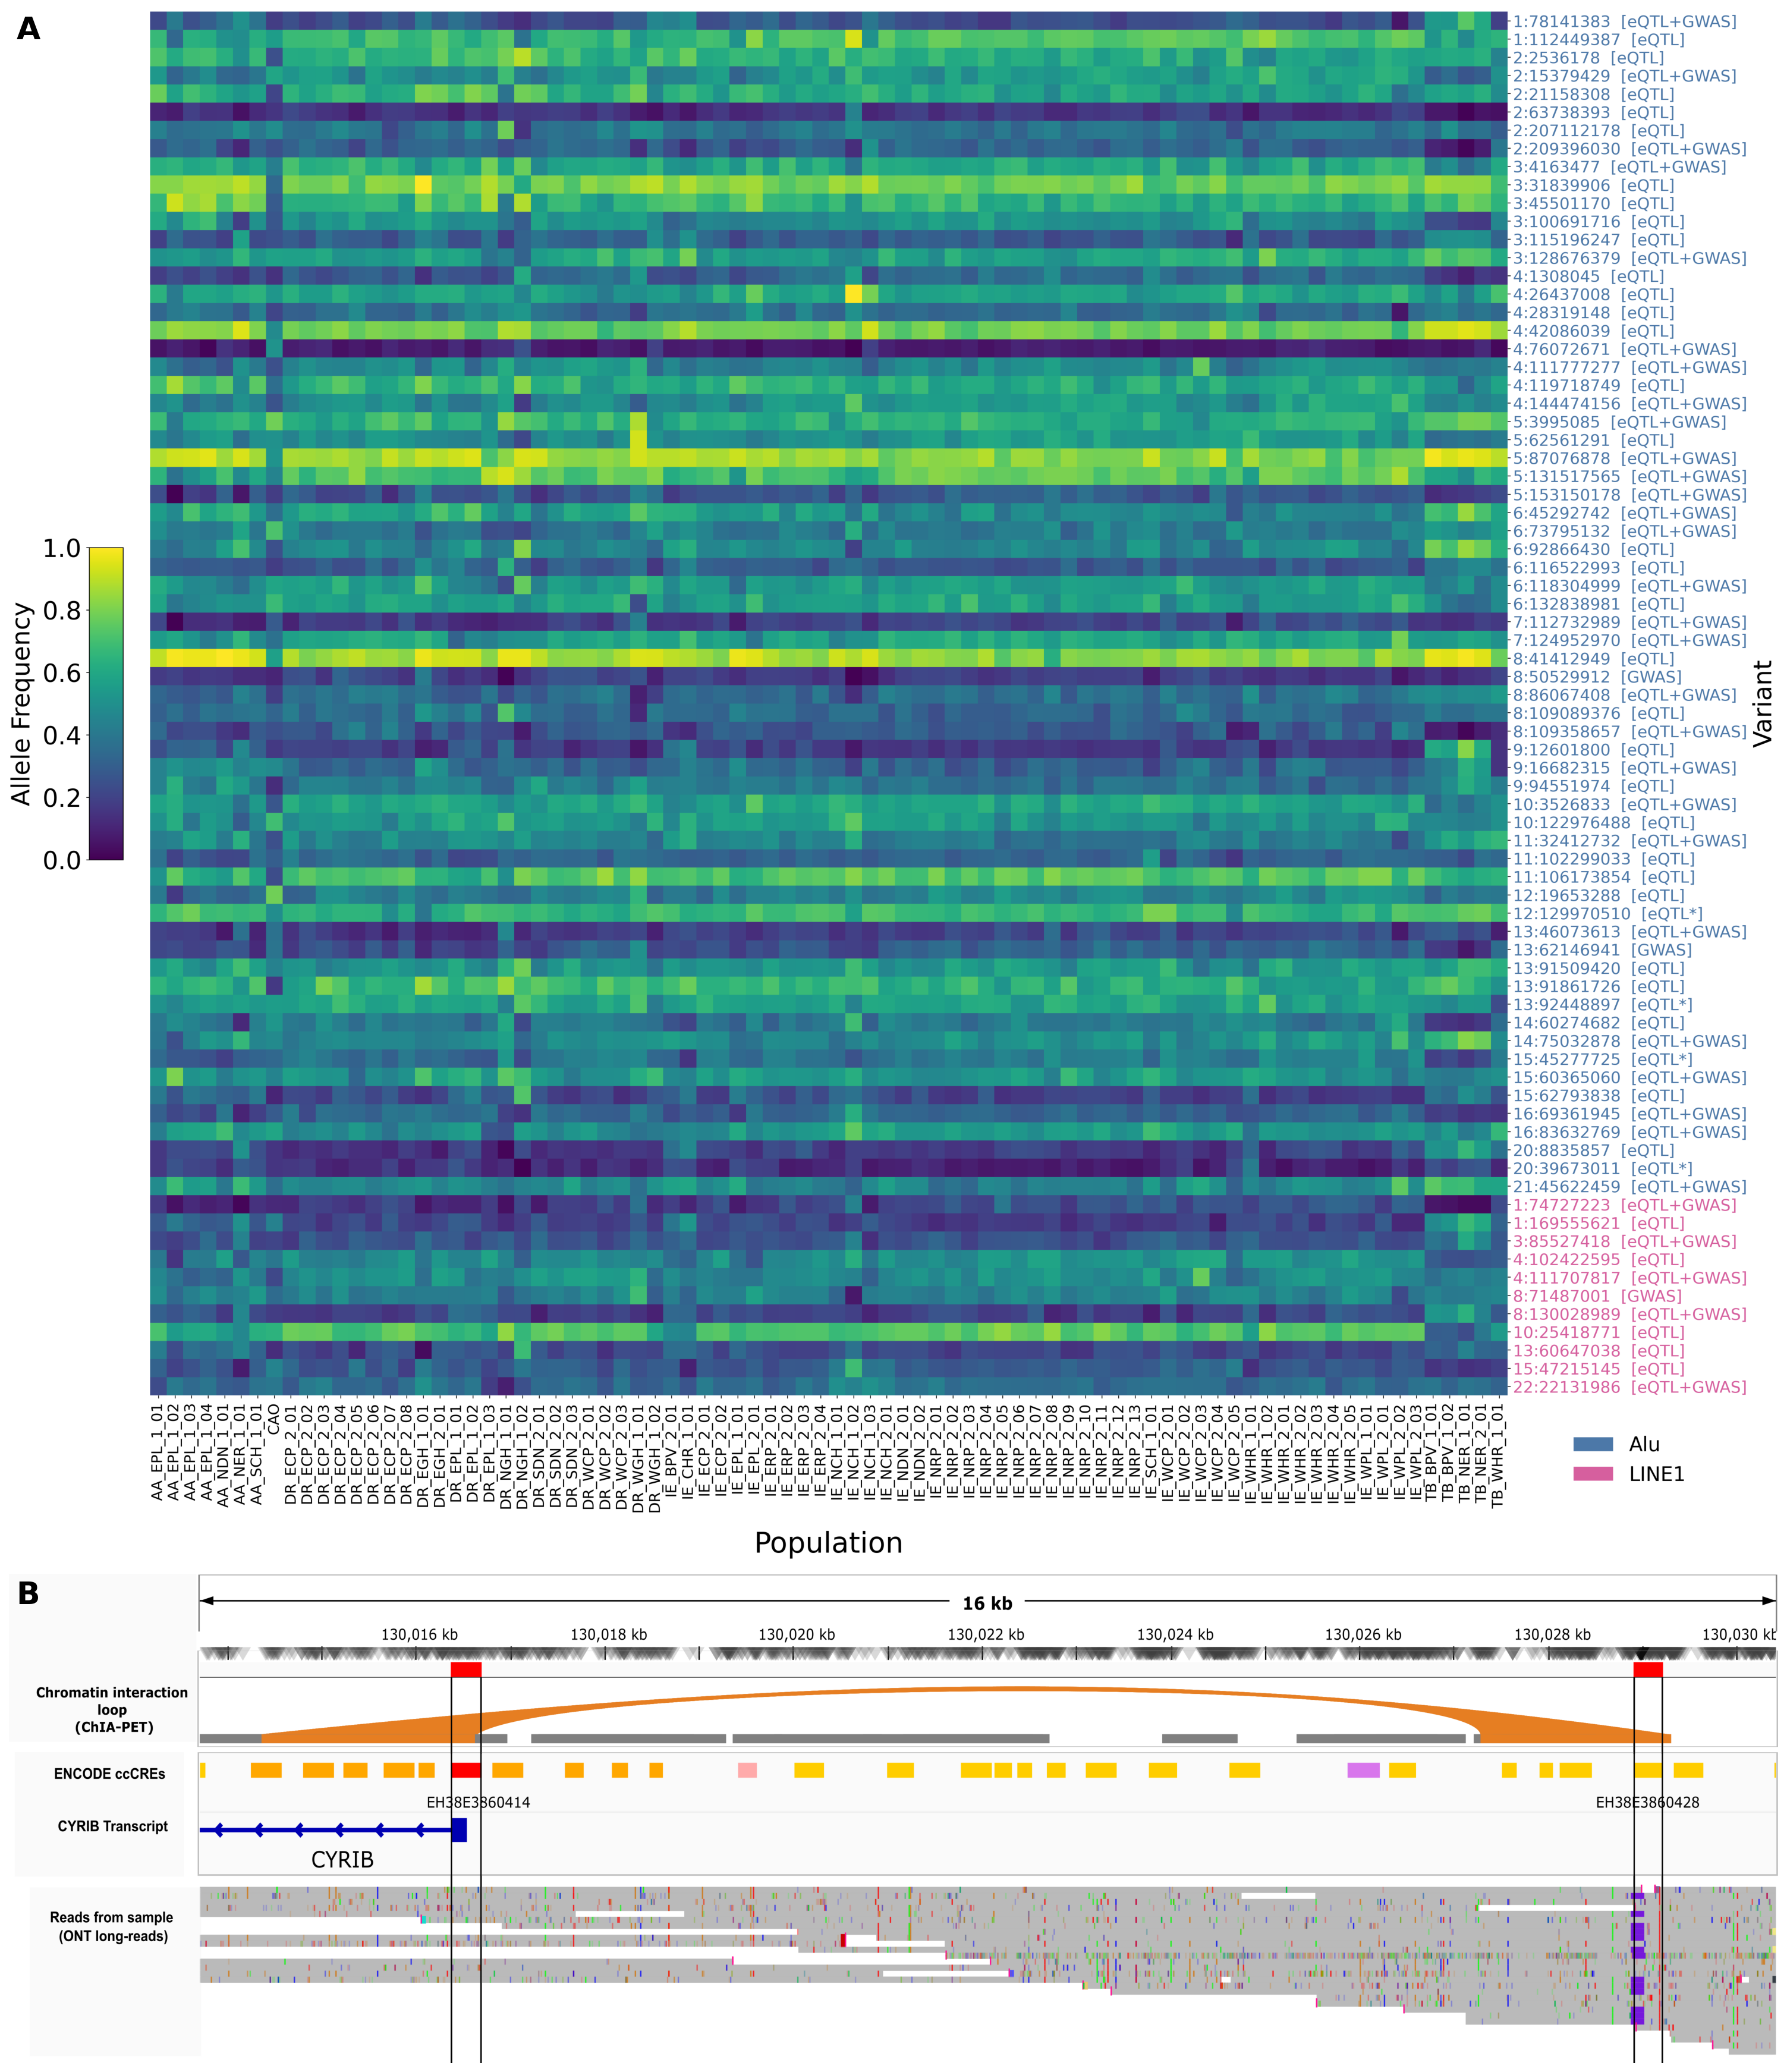


Saved: /gpfs/data/user/shreyags/TE_work/new_results/manuscript/figures/figure3/figure3_assembled.png


In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import os

PANEL_A_PATH = "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/figures/figure3/panel_A_composite.png"
PANEL_B_PATH = "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/figures/figure3/CYRIB_edited_final_final.png"
OUTFILE      = "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/figures/figure3/figure3_assembled.png"

print(PANEL_A_PATH)
print("Exists:", os.path.exists(PANEL_A_PATH))
print("Modified:", os.path.getmtime(PANEL_A_PATH))
print("PIL size:", Image.open(PANEL_A_PATH).size)

DPI = 300
GAP_IN = 0.15          # vertical gap between panels, in inches
LABEL_FONTSIZE = 25
LABEL_PAD_IN = 0.08   

img_a = mpimg.imread(PANEL_A_PATH)
img_b = mpimg.imread(PANEL_B_PATH)

h_a_px, w_a_px = img_a.shape[0], img_a.shape[1]
h_b_px, w_b_px = img_b.shape[0], img_b.shape[1]

w_a_in, h_a_in = w_a_px / DPI, h_a_px / DPI
w_b_in, h_b_in = w_b_px / DPI, h_b_px / DPI

fig_width_in  = max(w_a_in, w_b_in)
fig_height_in = h_a_in + h_b_in + GAP_IN

print(f"Panel A: {w_a_px}x{h_a_px}px  ({w_a_in:.2f}x{h_a_in:.2f}in)")
print(f"Panel B: {w_b_px}x{h_b_px}px  ({w_b_in:.2f}x{h_b_in:.2f}in)")
print(f"Composite: {fig_width_in:.2f}x{fig_height_in:.2f}in")

fig = plt.figure(figsize=(fig_width_in, fig_height_in), facecolor="white")

ax_a = fig.add_axes([0, (h_b_in + GAP_IN) / fig_height_in,
                      w_a_in / fig_width_in, h_a_in / fig_height_in])
ax_a.imshow(img_a)
ax_a.axis("off")

ax_b = fig.add_axes([0, 0,
                      w_b_in / fig_width_in, h_b_in / fig_height_in])
ax_b.imshow(img_b)
ax_b.axis("off")

label_pad_frac_x = LABEL_PAD_IN / fig_width_in
label_pad_frac_y_a = LABEL_PAD_IN / h_a_in
label_pad_frac_y_b = LABEL_PAD_IN / h_b_in

ax_a.text(label_pad_frac_x * w_a_px, label_pad_frac_y_a * h_a_px, "A",
          transform=ax_a.transData, fontsize=LABEL_FONTSIZE, fontweight="bold",
          ha="left", va="top", color="black")

ax_b.text(label_pad_frac_x * w_b_px, label_pad_frac_y_b * h_b_px, "B",
          transform=ax_b.transData, fontsize=LABEL_FONTSIZE, fontweight="bold",
          ha="left", va="top", color="black")

fig.savefig(OUTFILE, dpi=DPI, facecolor="white")
plt.show()
print(f"\nSaved: {OUTFILE}")

  [INS eQTL] parsed columns: ['te_class', 'te_variant', 'proxy_snp', 'r2', 'gene_id', 'gene_name', 'tissue', 'slope', 'slope_se', 'pval_beta', 'qval']
  [INS eQTL] Significant rows (q<0.05): 303 / 303
  [INS eQTL] lookup entries: 158
  [INS GWAS] parsed columns: ['variant_type', 'te_variant', 'proxy_snp', 'SNPS', 'r2', 'MAPPED_GENE', 'DISEASE/TRAIT', 'P-VALUE', 'OR or BETA', '95% CI (TEXT)', 'snp_chr', 'snp_pos', 'DATE ADDED TO CATALOG', 'PUBMEDID', 'FIRST AUTHOR', 'DATE', 'JOURNAL', 'LINK', 'STUDY', 'INITIAL SAMPLE SIZE', 'REPLICATION SAMPLE SIZE', 'REGION', 'CHR_ID', 'CHR_POS', 'REPORTED GENE(S)', 'UPSTREAM_GENE_ID', 'DOWNSTREAM_GENE_ID', 'SNP_GENE_IDS', 'UPSTREAM_GENE_DISTANCE', 'DOWNSTREAM_GENE_DISTANCE', 'STRONGEST SNP-RISK ALLELE', 'MERGED', 'SNP_ID_CURRENT', 'CONTEXT', 'INTERGENIC', 'RISK ALLELE FREQUENCY', 'PVALUE_MLOG', 'P-VALUE (TEXT)', 'PLATFORM [SNPS PASSING QC]', 'CNV']
  [INS GWAS] lookup entries: 131

Building script-2 cross-check index...
  Using causal column: 'isCausa

/gpfs/data/user/shreyags/.local/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


[COMBINED] Saved PDF: /gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_figures/panel_A_ALU_LINE1_combined_supplemental.pdf
[COMBINED] Saved PNG: (5802, 8458)


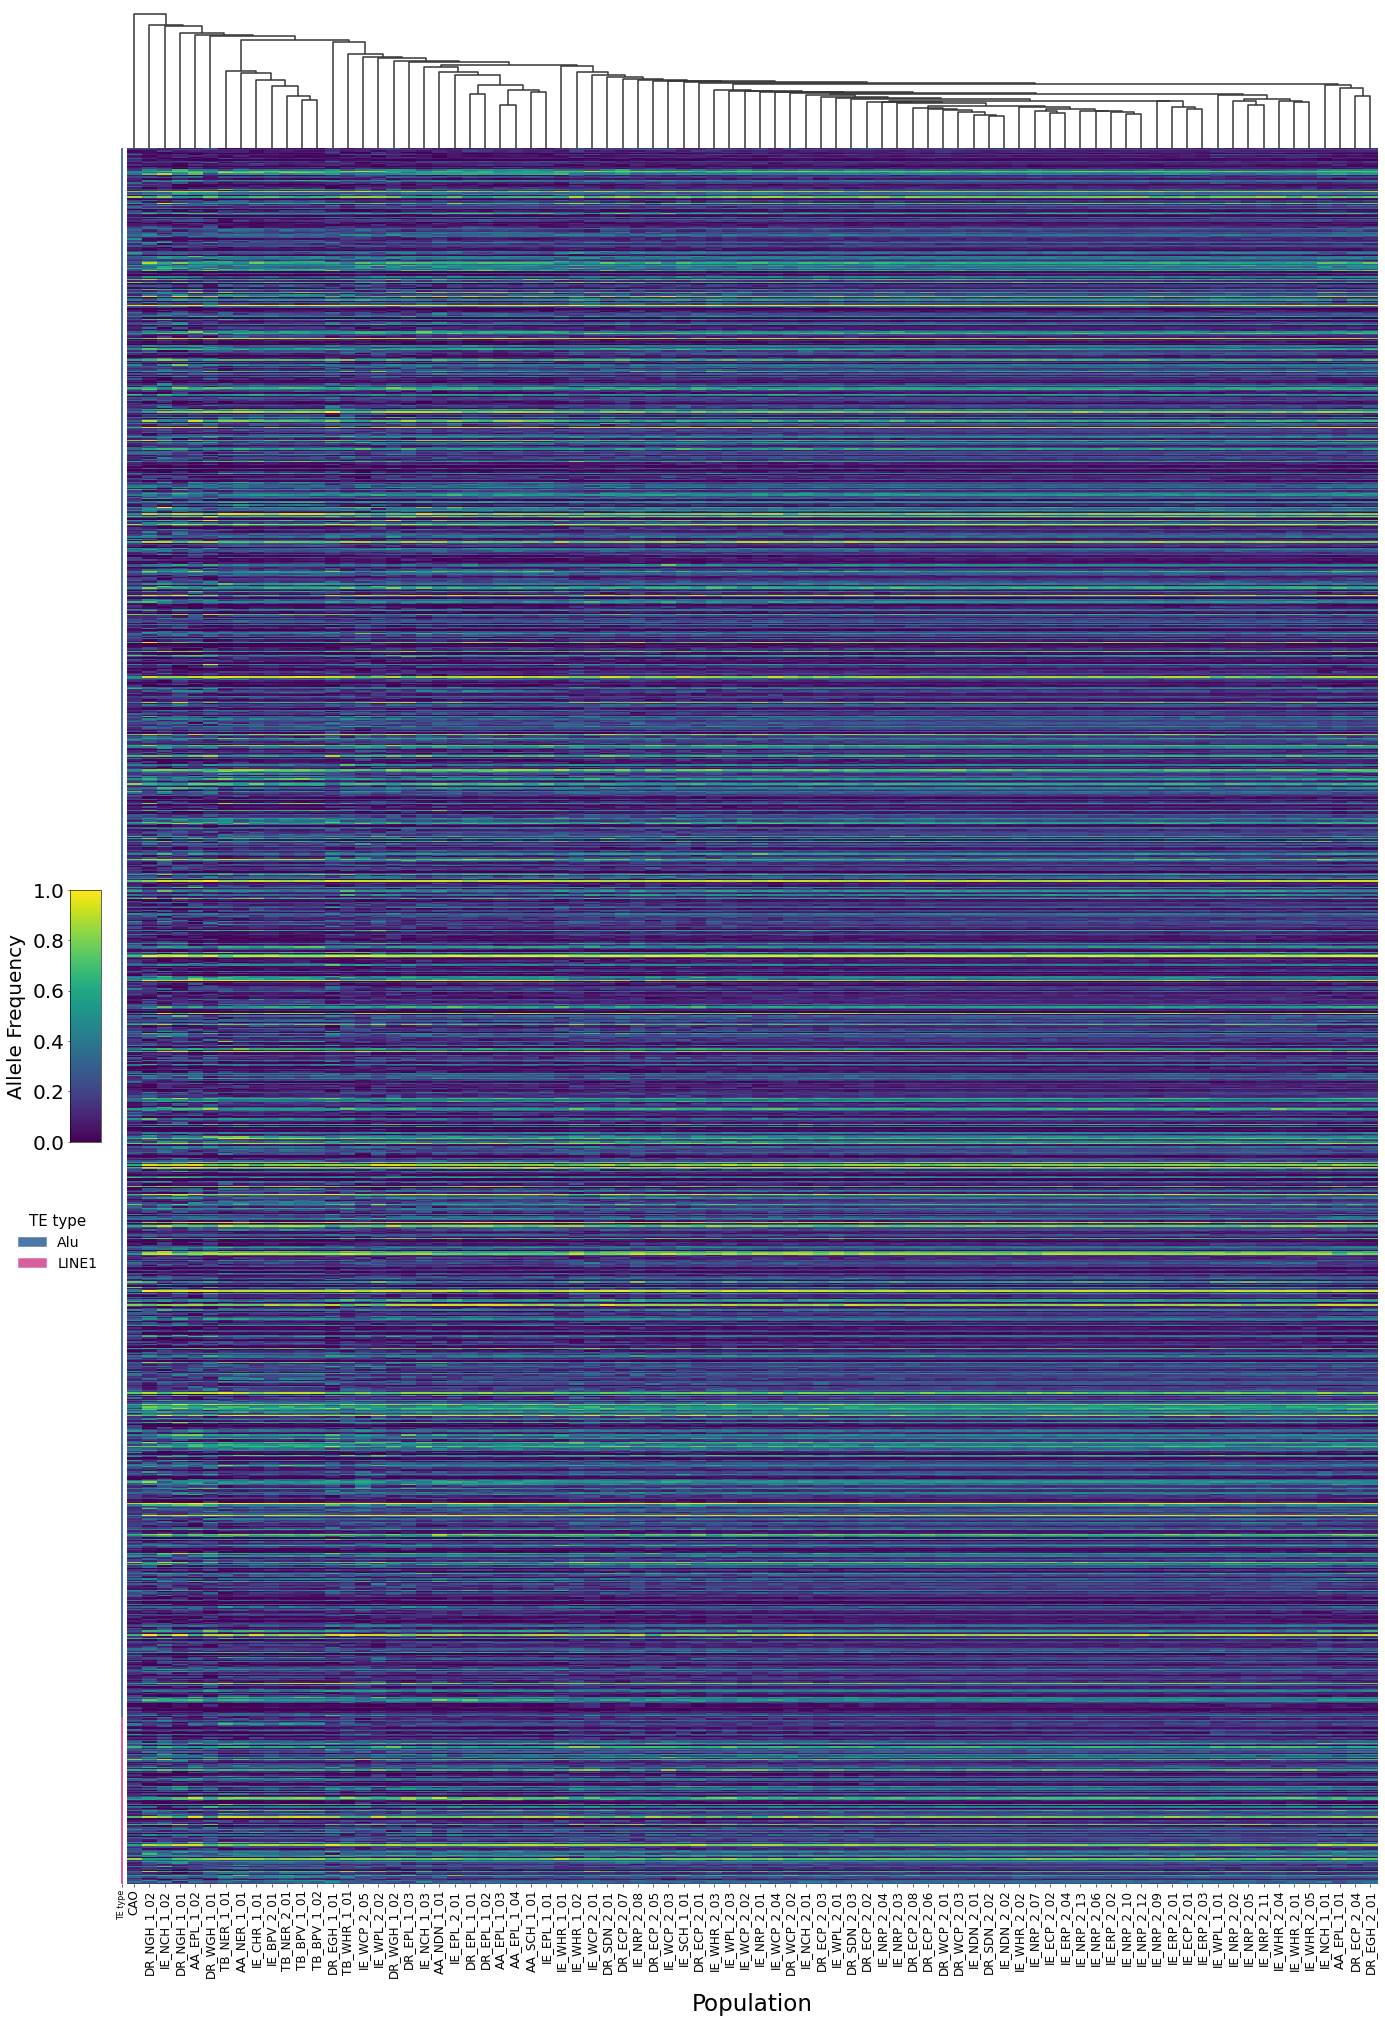


Done.


In [3]:
import os
from collections import defaultdict
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from PIL import Image
import fig_style as S

S.set_style()

Image.MAX_IMAGE_PIXELS = None

OUTDIR = "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_figures/"

AF_FILE       = "/gpfs/data/user/shreyags/TE_work/analysis/pop_af_out_new/INS_pop_af.tsv"
INS_EQTL_FILE = "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_tables/mei_insertion_lead_eQTL_hits.csv"
INS_GWAS_FILE = "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_tables/gwas_ld_hits_insertions.csv"

ALU_INS_SITES        = "/gpfs/data/user/shreyags/heatmaps_fig2_content/dedup_eqtl_alu_ins.txt"
LINE1_INS_SITES      = "/gpfs/data/user/shreyags/heatmaps_fig2_content/dedup_eqtl_line1_ins.txt"
ALU_INS_GWAS_SITES   = "/gpfs/data/user/shreyags/heatmaps_fig2_content/dedup_gwas_alu_ins.txt"
LINE1_INS_GWAS_SITES = "/gpfs/data/user/shreyags/heatmaps_fig2_content/dedup_gwas_line1_ins.txt"

INS_TSV    = "/gpfs/data/user/shweta_lab/data/TE/eqtls/eqtls_gtex_hg38_INS.tsv"
BP_BUFFER  = 20

ALU_INS_COLOR   = S.TE_PALETTE["Alu"]
LINE1_INS_COLOR = S.TE_PALETTE["LINE1"]

RANGE_THRESHOLD         = 0.4
RANGE_THRESHOLD_S2_ONLY = 0.6
QVAL_THRESHOLD          = 0.05

EXCLUDE_VARIANTS = {}

APPLY_FILTERS = False   # keep all variants, no range/annotated/exclude filtering
COL_CLUSTER   = True    
ROW_CLUSTER   = False   
CAT_ROW_HEIGHT       = 0.02
CAT_MIN_FIG_HEIGHT   = 4.0

CAT_DENDRO_RATIO     = (0.001, 0.075)

CBAR_SIZE = "2.5%"
CBAR_PAD  = "2.0%"
CBAR_HEIGHT_IN = 3.5

XTICK_PAD = 3

ROW_COLORS_WIDTH = 0.03
MPL_MAX_PIXELS_PER_DIM = 60000
TARGET_PNG_DPI = 300
PDF_DPI = 72  

os.makedirs(OUTDIR, exist_ok=True)

af = pd.read_csv(AF_FILE, sep="\t")

def normalise_te_variant(v):
    v = str(v).strip()
    if not v.startswith("chr"):
        v = "chr" + v
    parts = v.split(":")
    kept = [parts[0]]
    for p in parts[1:]:
        if p.lstrip("-").isdigit():
            kept.append(p)
        else:
            break
    return ":".join(kept)

def display_variant(v):
    v = str(v)
    return v[3:] if v.startswith("chr") else v

def chrom_sort_key(variant):
    parts = str(variant).split(":")
    chrom  = parts[0][3:] if parts[0].startswith("chr") else parts[0]
    if chrom.isdigit():
        chrom_num = int(chrom)
    elif chrom.upper() == "X":
        chrom_num = 23
    elif chrom.upper() == "Y":
        chrom_num = 24
    elif chrom.upper() in ("M", "MT"):
        chrom_num = 25
    else:
        chrom_num = 99
    pos = 0
    if len(parts) > 1 and parts[1].lstrip("-").isdigit():
        pos = int(parts[1])
    return (chrom_num, pos)

def build_eqtl_lookup(path, label):
    df = pd.read_csv(path, sep=None, engine="python")
    print(f"  [{label} eQTL] parsed columns: {list(df.columns)}")
    df["variant_norm"] = df["te_variant"].apply(normalise_te_variant)

    qval_col = "qval"
    r2_col   = "r2"
    df[qval_col]      = pd.to_numeric(df[qval_col],      errors="coerce")
    df[r2_col]        = pd.to_numeric(df[r2_col],        errors="coerce")
    df["pval_beta"]   = pd.to_numeric(df["pval_beta"],   errors="coerce")

    n_sig = (df[qval_col] < QVAL_THRESHOLD).sum()
    print(f"  [{label} eQTL] Significant rows (q<{QVAL_THRESHOLD}): {n_sig} / {len(df)}")

    df = df.sort_values("pval_beta")

    records = []
    for variant_norm, group in df.groupby("variant_norm", sort=False):
        top_hit = group.iloc[0]
        records.append({"variant": variant_norm, "gene_name": top_hit["gene_name"],
                        "slope": top_hit["slope"], "r2": top_hit[r2_col]})

    lookup = pd.DataFrame(records).set_index("variant")
    print(f"  [{label} eQTL] lookup entries: {len(lookup)}")
    return lookup

def build_gwas_lookup(path, label):
    # sep=None + engine="python" auto-detects the delimiter (comma or
    # tab) instead of assuming comma -- some of these ".csv" files are
    # actually tab-delimited.
    df = pd.read_csv(path, sep=None, engine="python")
    print(f"  [{label} GWAS] parsed columns: {list(df.columns)}")
    df["variant_norm"] = df["te_variant"].apply(normalise_te_variant)
    # not p_value/effect_size/trait -- map them here.
    df["p_value"]     = pd.to_numeric(df["P-VALUE"],  errors="coerce")
    df["r2"]          = pd.to_numeric(df["r2"],       errors="coerce")
    df["effect_size"] = pd.to_numeric(df["OR or BETA"], errors="coerce")
    df["trait"]       = df["DISEASE/TRAIT"]

    # No significance or effect-size filtering -- keep every variant's
    # single best (lowest p_value) hit, same treatment as the eQTL lookup.
    lookup = (
        df.sort_values("p_value")
          .groupby("variant_norm", as_index=False).first()
          [["variant_norm","trait","MAPPED_GENE","r2","effect_size"]]
          .rename(columns={"variant_norm":"variant","MAPPED_GENE":"gwas_gene","r2":"gwas_r2"})
          .set_index("variant")
    )
    print(f"  [{label} GWAS] lookup entries: {len(lookup)}")
    return lookup

eqtl_lookup_ins = build_eqtl_lookup(INS_EQTL_FILE, "INS")
gwas_lookup_ins  = build_gwas_lookup(INS_GWAS_FILE,  "INS")

def load_ins_sites(path):
    s = pd.read_csv(path, header=None, names=["variant"])
    s["variant"] = s["variant"].str.strip()
    return s

def build_mat(sites_df):
    heat    = af[af["variant"].isin(sites_df["variant"])].copy()
    af_cols = [c for c in heat.columns if c.endswith("_AF")]
    mat     = heat.set_index("variant")[af_cols].fillna(0)
    mat.columns = [c.replace("_AF","") for c in mat.columns]
    return mat

def build_mat_for_variants(variant_list):
    return build_mat(pd.DataFrame({"variant": list(variant_list)}))

def high_range_subset(mat, label):
    rng  = mat.max(axis=1) - mat.min(axis=1)
    var  = mat.var(axis=1)
    high = rng[rng > RANGE_THRESHOLD].index
    print(f"  [{label}] {len(high)} / {len(mat)} variants with range > {RANGE_THRESHOLD}")
    return mat.loc[high], rng, var

print("\nBuilding script-2 cross-check index...")

def parse_af_variant(v):
    parts = str(v).split(":")
    chrom = parts[0] if parts[0].startswith("chr") else "chr" + parts[0]
    try:    start = int(parts[1])
    except: return None, None, None
    end = int(parts[2]) if len(parts) >= 3 and parts[2].lstrip("-").isdigit() else None
    return chrom, start, end

def parse_tsv_pos(s):
    parts = str(s).split(":")
    chrom = parts[0] if parts[0].startswith("chr") else "chr" + parts[0]
    try:    pos = int(parts[1])
    except: return None, None
    return chrom, pos

parsed       = af["variant"].apply(parse_af_variant)
af["af_chrom"] = [p[0] for p in parsed]
af["af_start"] = [p[1] for p in parsed]
af["af_end"]   = [p[2] for p in parsed]
af_ins_full    = af[af["af_end"].isna()].copy()

def build_pos_index(df):
    idx = defaultdict(list)
    for i, row in df.iterrows():
        idx[row["af_chrom"]].append((row["af_start"], i))
    return {ch: sorted(e) for ch, e in idx.items()}

ins_pos_idx_full = build_pos_index(af_ins_full)

def find_af_matches(chrom, pos, pos_index, buffer=BP_BUFFER):
    return [i for (af_pos, i) in pos_index.get(chrom, []) if abs(af_pos - pos) <= buffer]

def match_script2_eqtls(tsv_path, pos_index):
    df = pd.read_csv(tsv_path, sep="\t", dtype=str)
    causal_col = "isCausal" if "isCausal" in df.columns else df.columns[8]
    print(f"  Using causal column: '{causal_col}'")
    collapsed = {}
    for _, row in df.iterrows():
        chrom, pos = parse_tsv_pos(row["chr_pos_hg38"])
        if chrom is None:
            continue
        hits = find_af_matches(chrom, pos, pos_index)
        if not hits:
            continue
        best_idx       = min(hits, key=lambda i: abs(af.loc[i, "af_start"] - pos))
        af_variant_id  = af.loc[best_idx, "variant"]
        entry          = collapsed.setdefault(af_variant_id, {
            "gene_betas":  {},
            "te_type":     row.get("te_type"),
            "gene_causal": {}
        })
        entry["gene_betas"][row["gene_symbol"]]  = row["beta"]
        entry["gene_causal"][row["gene_symbol"]] = str(row.get(causal_col,"")).strip().lower() == "true"
    return collapsed

script2_eqtl_map_full = match_script2_eqtls(INS_TSV, ins_pos_idx_full)
print(f"  Script-2 matches for {len(script2_eqtl_map_full)} AF insertion variants")

script2_eqtl_map = {v: d["gene_betas"] for v, d in script2_eqtl_map_full.items()}
S2_COLOR_BY_TE = {"ALU": ALU_INS_COLOR, "LINE1": LINE1_INS_COLOR}

def build_final_matrix_for_type(vtype, eqtl_sites_path, gwas_sites_path, color):
    eqtl_sites = load_ins_sites(eqtl_sites_path)
    gwas_sites = load_ins_sites(gwas_sites_path)

    all_variants = pd.concat([eqtl_sites[["variant"]], gwas_sites[["variant"]]]).drop_duplicates("variant")
    mat = build_mat(all_variants)

    if APPLY_FILTERS:
        mat_use, rng, var = high_range_subset(mat, vtype)
    else:
        rng, var = mat.max(axis=1) - mat.min(axis=1), mat.var(axis=1)
        mat_use = mat
        print(f"  [{vtype}] no filtering: keeping all {len(mat_use)} variants")

    eqtl_map = {v: eqtl_lookup_ins for v in mat_use.index}
    gwas_map = {v: gwas_lookup_ins for v in mat_use.index}
    colors_map = {v: color for v in mat_use.index}

    final_mat = mat_use.copy()

    if APPLY_FILTERS:
        annotated = [v for v in final_mat.index if v in eqtl_map[v].index or v in gwas_map[v].index]
        final_mat = final_mat.loc[annotated]
        before_excl = len(final_mat)
        final_mat   = final_mat[~final_mat.index.isin(EXCLUDE_VARIANTS)]
        print(f"  [{vtype}] Explicitly excluded {before_excl - len(final_mat)} variants")
    else:
        print(f"  [{vtype}] APPLY_FILTERS=False: keeping all {len(final_mat)} variants")

    script2_only_candidates = [
        v for v, d in script2_eqtl_map_full.items()
        if d.get("te_type") == vtype.replace("_INS", "") and v not in final_mat.index
    ]
    rescued = []
    if script2_only_candidates:
        cand_mat = build_mat_for_variants(script2_only_candidates)
        cand_rng = cand_mat.max(axis=1) - cand_mat.min(axis=1)
        cand_var = cand_mat.var(axis=1)

        if APPLY_FILTERS:
            rescued = [v for v in cand_rng[cand_rng > RANGE_THRESHOLD_S2_ONLY].index
                       if v not in EXCLUDE_VARIANTS]
        else:
            rescued = list(cand_mat.index)

        print(f"  [{vtype}] Rescued script-2-only variants: {len(rescued)}")
        if rescued:
            final_mat = pd.concat([final_mat, cand_mat.loc[rescued]])
            for v in rescued:
                colors_map[v] = color
                eqtl_map[v]   = eqtl_lookup_ins.iloc[0:0]
                gwas_map[v]   = gwas_lookup_ins.iloc[0:0]

    final_mat = final_mat[~final_mat.index.duplicated(keep="first")]
    script2_only_variants = set(rescued)

    final_mat = final_mat.loc[sorted(final_mat.index, key=chrom_sort_key)]

    print(f"  [{vtype}] Final matrix: {len(final_mat)} variants x {final_mat.shape[1]} populations\n")

    return final_mat, eqtl_map, gwas_map, colors_map, script2_only_variants

def _base_clustermap(figsize, mat, row_colors, dendrogram_ratio=(0.001, 0.075), fig_height=None):
    if fig_height is None:
        fig_height = max(12, len(mat) * 0.28)

    fig_width = figsize[0]

    g = sns.clustermap(
        mat,
        cmap="viridis",
        figsize=(fig_width, fig_height),
        method="average", metric="euclidean",
        row_cluster=ROW_CLUSTER, col_cluster=COL_CLUSTER,
        dendrogram_ratio=dendrogram_ratio,
        colors_ratio=(ROW_COLORS_WIDTH / fig_width, 0.02),
        row_colors=row_colors,
        linewidths=0,
        xticklabels=True, yticklabels=False,
        cbar_pos=None,
    )

    g.fig.set_facecolor("white")
    g.ax_heatmap.set_facecolor("white")
    g.ax_heatmap.spines["top"].set_visible(False)
    g.ax_heatmap.spines["right"].set_visible(False)

    g.ax_heatmap.set_yticks([])
    g.ax_heatmap.set_ylabel("")

    plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=12, ha="center")

    g.ax_heatmap.tick_params(axis="x", pad=XTICK_PAD)

    g.ax_heatmap.set_xlabel("Population", fontsize=23, labelpad=15)

    pos = g.ax_heatmap.get_position()
    cbar_w_frac = float(CBAR_SIZE.strip("%")) / 100 * pos.width
    cbar_pad_frac = float(CBAR_PAD.strip("%")) / 100 * pos.width
    cbar_h_frac = CBAR_HEIGHT_IN / fig_height
    cbar_h_frac = min(cbar_h_frac, pos.height)
    cbar_y0 = pos.y0 + (pos.height - cbar_h_frac) / 2
    cax = g.fig.add_axes([pos.x0 - cbar_pad_frac - cbar_w_frac, cbar_y0,
                          cbar_w_frac, cbar_h_frac])
    cbar = g.fig.colorbar(g.ax_heatmap.collections[0], cax=cax)
    cbar.ax.yaxis.set_ticks_position("left")
    cbar.ax.yaxis.set_label_position("left")
    cbar.set_label("Allele Frequency", labelpad=6, fontsize=20)
    cbar.ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
    cbar.ax.tick_params(labelsize=20)
    g.cax = cax

    for coll in g.ax_col_dendrogram.collections:
        coll.set_linewidth(1.5)

    for coll in g.ax_heatmap.collections:
        coll.set_rasterized(False)

    if cbar.solids is not None:
        cbar.solids.set_rasterized(False)

    for coll in g.ax_row_colors.collections:
        coll.set_rasterized(False)

    g.fig.set_dpi(72)

    return g

def safe_png_dpi(fig_height_in, target_dpi=TARGET_PNG_DPI):
    """
    Cap PNG save DPI so height (in inches) * dpi never exceeds Matplotlib's
    Agg raster hard limit (~65536 px per dimension). PDF is vector and
    doesn't need this -- it saves at full quality regardless of height.
    """
    max_dpi_for_height = MPL_MAX_PIXELS_PER_DIM / fig_height_in
    dpi = min(target_dpi, max_dpi_for_height)
    if dpi < target_dpi:
        print(f"  [png dpi] figure height {fig_height_in:.1f}in -> "
              f"reducing PNG dpi {target_dpi} -> {dpi:.1f} to stay under the pixel limit")
    return dpi

def make_combined_heatmap(mat, row_type_colors, outfile_stub):
    fig_height = max(CAT_MIN_FIG_HEIGHT, len(mat) * CAT_ROW_HEIGHT)
    print(f"\n[COMBINED] Figure height for {len(mat)} rows: {fig_height:.1f} in")

    row_colors = pd.Series(row_type_colors, name="TE type")

    g = _base_clustermap(
        (18, None), mat, row_colors,
        dendrogram_ratio=CAT_DENDRO_RATIO,
        fig_height=fig_height,
    )
    
    legend_handles = [
        mpatches.Patch(color=ALU_INS_COLOR, label="Alu"),
        mpatches.Patch(color=LINE1_INS_COLOR, label="LINE1"),
    ]
   
    cbar_pos = g.cax.get_position()
    g.fig.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(cbar_pos.x0 - 0.05, cbar_pos.y0 - 0.03),
        bbox_transform=g.fig.transFigure,
        frameon=False,
        fontsize=14,
        title="TE type",
        title_fontsize=15,
    )

    g.fig.text(1.05, 0.5, "", transform=g.fig.transFigure)

    pdf_outfile = os.path.join(OUTDIR, f"{outfile_stub}.pdf")
    g.fig.savefig(
        pdf_outfile,
        dpi=PDF_DPI,
        bbox_inches="tight",
        pad_inches=0.15,
        facecolor="white"
    )
    print("[COMBINED] Saved PDF:", pdf_outfile)

    png_dpi = safe_png_dpi(fig_height)
    png_outfile = os.path.join(OUTDIR, f"{outfile_stub}.png")
    g.fig.savefig(
        png_outfile,
        dpi=png_dpi,
        bbox_inches="tight",
        pad_inches=0.15,
        facecolor="white"
    )
    print("[COMBINED] Saved PNG:", Image.open(png_outfile).size)

    plt.show()
    plt.close(g.fig)

alu_mat, alu_eqtl_map, alu_gwas_map, alu_colors_map, alu_s2_only = build_final_matrix_for_type(
    "ALU_INS", ALU_INS_SITES, ALU_INS_GWAS_SITES, ALU_INS_COLOR
)
line1_mat, line1_eqtl_map, line1_gwas_map, line1_colors_map, line1_s2_only = build_final_matrix_for_type(
    "LINE1_INS", LINE1_INS_SITES, LINE1_INS_GWAS_SITES, LINE1_INS_COLOR
)

combined_mat = pd.concat([alu_mat, line1_mat])
combined_mat = combined_mat[~combined_mat.index.duplicated(keep="first")]

combined_colors_map = {**alu_colors_map, **line1_colors_map}
row_type_colors = {v: combined_colors_map[v] for v in combined_mat.index}

print(f"\n[COMBINED] Final matrix: {len(combined_mat)} variants x {combined_mat.shape[1]} populations "
      f"({len(alu_mat)} ALU + {len(line1_mat)} LINE1)\n")

make_combined_heatmap(
    combined_mat, row_type_colors,
    outfile_stub="panel_A_ALU_LINE1_combined_supplemental"
)

print("\nDone.")